# TP — Régression Linéaire



## Objectifs pédagogiques

À la fin de cet exercice, vous serez capable de :

- Appliquer une régression linéaire simple sur un jeu de données réel
- Appliquer une régression linéaire multiple pour améliorer les performances d’un modèle
- Interpréter les résultats et comparer les valeurs réelles aux valeurs prédites
- Visualiser les performances d’un modèle de régression


## 1. Chargement du dataset

In [1]:
import pandas as pd

path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"

df = pd.read_csv(path)

df.head()


,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


## 2. Exploration rapide des données

In [2]:
# Dimensions du dataset
print(df.shape)

# Types des colonnes
print(df.dtypes)

# Valeurs manquantes
print(df.isnull().sum())

# Corrélations avec Price
df.corr(numeric_only=True)["Price"].sort_values(ascending=False)


(238, 16)
Unnamed: 0.1          int64
Unnamed: 0            int64
Manufacturer         object
Category              int64
GPU                   int64
OS                    int64
CPU_core              int64
Screen_Size_inch    float64
CPU_frequency       float64
RAM_GB                int64
Storage_GB_SSD        int64
Weight_pounds       float64
Price                 int64
Price-binned         object
Screen-Full_HD        int64
Screen-IPS_panel      int64
dtype: object
Unnamed: 0.1        0
Unnamed: 0          0
Manufacturer        0
Category            0
GPU                 0
OS                  0
CPU_core            0
Screen_Size_inch    0
CPU_frequency       0
RAM_GB              0
Storage_GB_SSD      0
Weight_pounds       0
Price               0
Price-binned        0
Screen-Full_HD      0
Screen-IPS_panel    0
dtype: int64


,Price
Price,1.000000
RAM_GB,0.549297
CPU_core,0.459398
CPU_frequency,0.366666
Unnamed: 0,0.321933
Unnamed: 0.1,0.321933
GPU,0.288298
Category,0.286243
Storage_GB_SSD,0.243421
Screen-IPS_panel,0.021075


## 3. Régression Linéaire Simple


### Travail demandé

- Variable indépendante : `CPU_frequency`
- Variable cible : `Price`
- Construire et entraîner le modèle
- Effectuer des prédictions
- Comparer les valeurs réelles et prédites


In [3]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
X = df[["CPU_frequency"]]
y = df["Price"]


In [5]:
lr = LinearRegression()

lr.fit(X, y)

print("Coefficient :", lr.coef_[0])
print("Intercept :", lr.intercept_)


Coefficient : 1485.1936264779172
Intercept : 253.6611706858214


In [6]:
print(f"Price = {lr.coef_[0]:.2f} * CPU_frequency + {lr.intercept_:.2f}")


Price = 1485.19 * CPU_frequency + 253.66


In [7]:
predictions_simple = lr.predict(X)

predictions_simple[:5]


array([1073.07834392, 1277.93263722, 1636.42765051, 1073.07834392,
       1175.50549057])

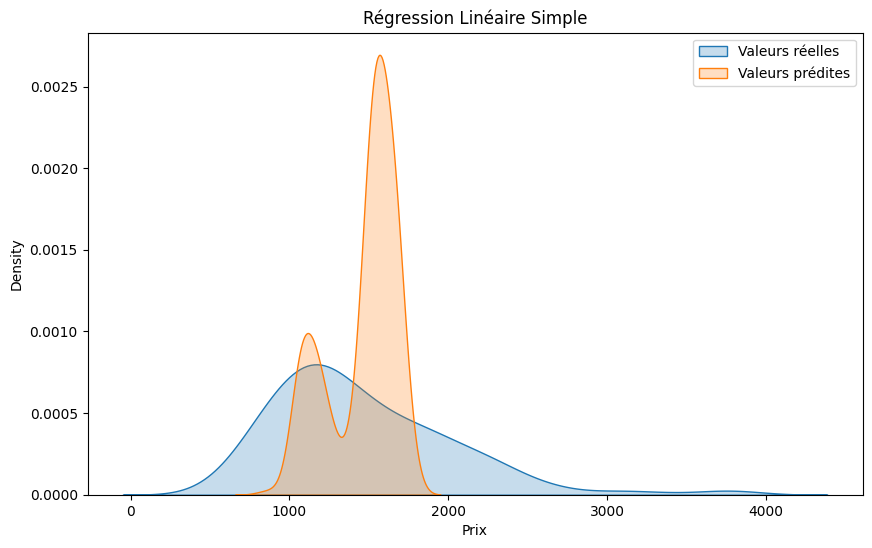

In [8]:
plt.figure(figsize=(10,6))

sns.kdeplot(y, label="Valeurs réelles", fill=True)
sns.kdeplot(predictions_simple, label="Valeurs prédites", fill=True)

plt.title("Régression Linéaire Simple")
plt.xlabel("Prix")
plt.legend()

plt.show()


## 4. Régression Linéaire Multiple


### Variables à utiliser

- CPU_frequency
- RAM_GB
- Storage_GB_SSD
- CPU_core
- OS
- GPU
- Category


In [9]:
features = [
    "CPU_frequency",
    "RAM_GB",
    "Storage_GB_SSD",
    "CPU_core",
    "OS",
    "GPU",
    "Category"
]

X_multi = df[features]
y_multi = df["Price"]

# Encodage des variables catégorielles
X_multi = pd.get_dummies(X_multi, drop_first=True)

X_multi.head()


,CPU_frequency,RAM_GB,Storage_GB_SSD,CPU_core,OS,GPU,Category
0,0.551724,8,256,5,1,2,4
1,0.689655,4,256,3,1,1,3
2,0.931034,8,256,7,1,1,3
3,0.551724,8,128,5,1,2,4
4,0.620690,8,256,7,1,2,4


In [10]:
lr_multi = LinearRegression()

lr_multi.fit(X_multi, y_multi)


LinearRegression()

In [11]:
predictions_multi = lr_multi.predict(X_multi)

predictions_multi[:5]


array([1345.51622771,  710.44905496, 1552.37242687, 1295.00681012,
       1543.13847022])

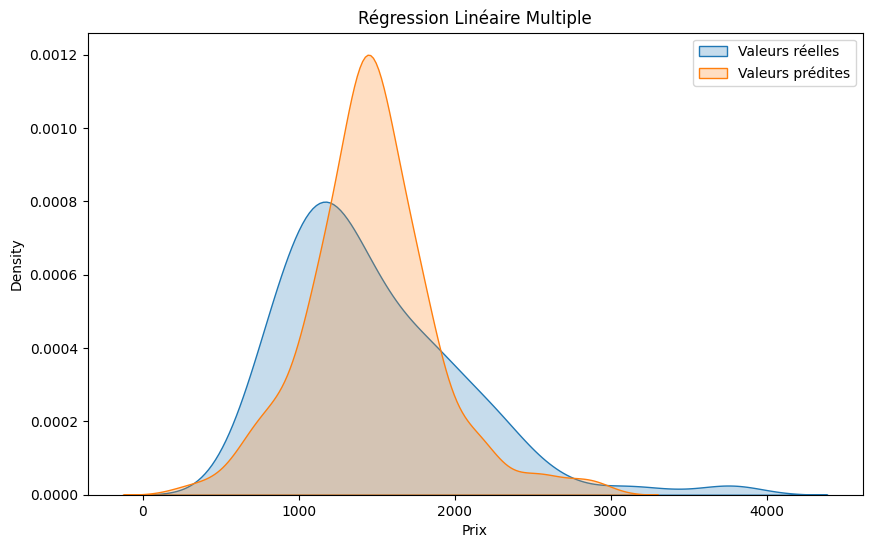

In [12]:
plt.figure(figsize=(10,6))

sns.kdeplot(y_multi, label="Valeurs réelles", fill=True)
sns.kdeplot(predictions_multi, label="Valeurs prédites", fill=True)

plt.title("Régression Linéaire Multiple")
plt.xlabel("Prix")
plt.legend()

plt.show()


## 5. Évaluation des modèles

In [13]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("=== Régression simple ===")
print("R² :", r2_score(y, predictions_simple))
print("MAE :", mean_absolute_error(y, predictions_simple))
print("MSE :", mean_squared_error(y, predictions_simple))

print()

print("=== Régression multiple ===")
print("R² :", r2_score(y_multi, predictions_multi))
print("MAE :", mean_absolute_error(y_multi, predictions_multi))
print("MSE :", mean_squared_error(y_multi, predictions_multi))


=== Régression simple ===
R² : 0.1344436321024326
MAE : 409.77276991809714
MSE : 284583.4405868629

=== Régression multiple ===
R² : 0.5082509055187374
MAE : 304.1380002192293
MSE : 161680.57263893107
